# Rossi Meshing Simulation — Analysis

Analysis of the pre-generated source distribution and 2D (r, θ) fission mesh tally.

1. **Source Distribution** — verify that the pre-generated source (`initial_source.h5`) is
   spatially uniform inside the core sphere.
2. **Fission Distribution** — visualise the fission tally on the 2D mesh (radial × polar)
   as both flat and physical-space heatmaps.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openmc
import scienceplots
from scipy import stats as sp_stats

from project.core.rossi_mesh import CORE_RADIUS, N_RADIAL, N_THETA, make_fission_mesh

plt.style.use(["science", "notebook", "grid", "high-vis"])

RESULTS_DIR = Path("../../results/rossi-meshing-simulation").resolve()
FIGURES_DIR = Path("../outputs/figures/rossi_meshing")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Reconstruct mesh
mesh = make_fission_mesh()
r_edges = np.asarray(mesh.r_grid)
theta_edges = np.asarray(mesh.theta_grid)
r_mid = 0.5 * (r_edges[:-1] + r_edges[1:])

# Load pre-generated source
df_src = openmc.read_source_file(str(RESULTS_DIR / "initial_source.h5")).to_dataframe()
mesh_ids = np.load(RESULTS_DIR / "source_mesh_ids.npy")

print(f"Mesh: {N_RADIAL} radial × {N_THETA} theta = {N_RADIAL * N_THETA:,} equal-volume cells")
print(f"Source particles loaded: {len(df_src):,}")
print(f"Results dir: {RESULTS_DIR}")

Mesh: 100 radial × 50 theta = 5,000 equal-volume cells
Source particles loaded: 1,000,000
Results dir: /home/itay/projects/initiation-project/project/results/rossi-meshing-simulation


## 1. Source Distribution Verification

The source file `initial_source.h5` was pre-generated by the simulation and used
via `FileSource` — these are the exact particles that were transported.

In [2]:
x = df_src["x"].to_numpy()
y = df_src["y"].to_numpy()
z = df_src["z"].to_numpy()
r = np.sqrt(x**2 + y**2 + z**2)

print(f"Max radius: {r.max():.5f} cm  (should be ≤ {CORE_RADIUS} cm)")
print(f"All inside core: {np.all(r <= CORE_RADIUS + 1e-9)}")

Max radius: 3.00000 cm  (should be ≤ 3.0 cm)
All inside core: True


### 1.1 Spatial distribution — x–z hexbin

Hexbin of the x–z projection. Uniform fill with no radial gradient confirms
the `PowerLaw(0, R, 2)` sampling produces a volumetrically uniform distribution.

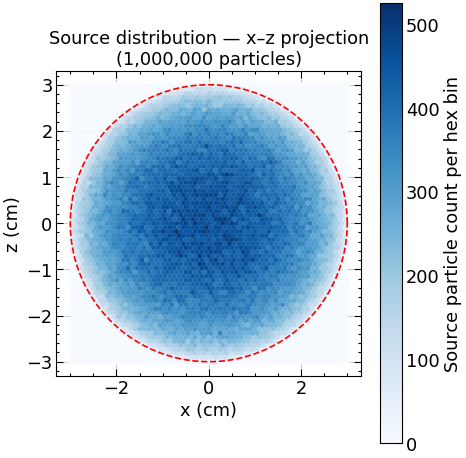

In [3]:
theta_ring = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots(figsize=(6, 6), dpi=80)
hb = ax.hexbin(x, z, gridsize=60, cmap="Blues", linewidths=0.2)
plt.colorbar(hb, ax=ax, label="Source particle count per hex bin")
ax.plot(
    CORE_RADIUS * np.cos(theta_ring),
    CORE_RADIUS * np.sin(theta_ring),
    "r--", lw=1.5,
)
ax.set_aspect("equal")
ax.set_xlabel("x (cm)")
ax.set_ylabel("z (cm)")
ax.set_title(f"Source distribution — x–z projection\n({len(df_src):,} particles)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "source_xz_hexbin.png", dpi=300, bbox_inches="tight")
plt.show()

### 1.2 Chi-squared uniformity test

With equal-volume mesh cells and a uniform source, each cell should contain
`N_particles / N_cells` particles on average. A chi-squared goodness-of-fit
test checks whether the observed cell counts are consistent with this expectation.

In [4]:
n_cells = N_RADIAL * N_THETA
cell_counts = np.bincount(mesh_ids[mesh_ids >= 0], minlength=n_cells)
expected = len(df_src) / n_cells

chi2_stat = np.sum((cell_counts - expected) ** 2 / expected)
p_value = 1.0 - sp_stats.chi2.cdf(chi2_stat, df=n_cells - 1)

rel_std_obs = cell_counts.std() / cell_counts.mean()
rel_std_poisson = 1.0 / np.sqrt(expected)

print(f"Expected particles per cell: {expected:.1f}")
print(f"Observed mean ± std: {cell_counts.mean():.1f} ± {cell_counts.std():.1f}")
print(f"Relative std: {rel_std_obs:.4f}  (Poisson expectation: {rel_std_poisson:.4f})")
print(f"Chi² statistic: {chi2_stat:.1f}  (df = {n_cells - 1})")
print(f"p-value: {p_value:.4f}")
print(f"Uniform distribution {'CONFIRMED' if p_value > 0.05 else 'REJECTED'} (α = 0.05)")

Expected particles per cell: 200.0
Observed mean ± std: 200.0 ± 14.3
Relative std: 0.0716  (Poisson expectation: 0.0707)
Chi² statistic: 5125.3  (df = 4999)
p-value: 0.1040
Uniform distribution CONFIRMED (α = 0.05)


### 1.3 Source counts per mesh cell — heatmaps

Two views of the same data: flat (r, cos θ) coordinates and a physical-space
meridional slice showing the actual sphere cross-section.

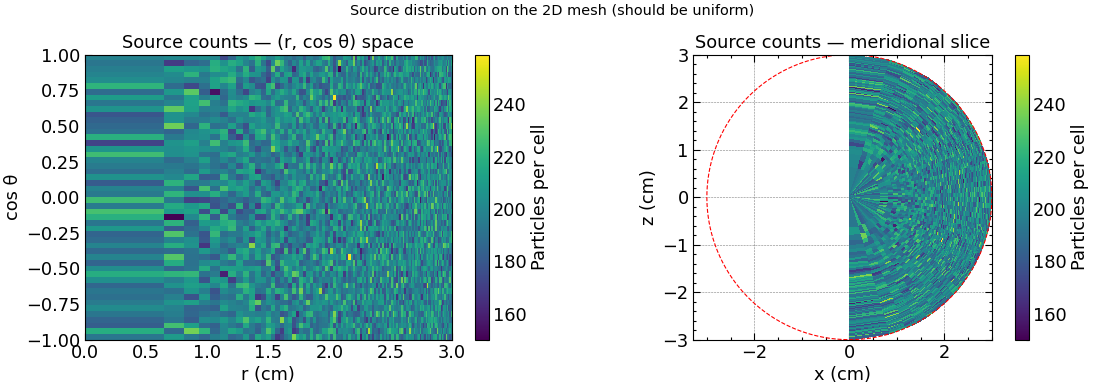

In [5]:
# Reshape counts to 2D: [i_theta, i_r] (r varies fastest in flat index)
counts_2d = cell_counts.reshape(N_THETA, N_RADIAL)

# Coordinate grids for the two plot styles
cos_theta_edges = np.cos(theta_edges)
R_grid, T_grid = np.meshgrid(r_edges, theta_edges)
X_phys = R_grid * np.sin(T_grid)
Z_phys = R_grid * np.cos(T_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=80)

# Left: flat (r, cos θ) pcolormesh
im0 = axes[0].pcolormesh(
    r_edges, cos_theta_edges, counts_2d,
    cmap="viridis", shading="flat",
)
plt.colorbar(im0, ax=axes[0], label="Particles per cell")
axes[0].set_xlabel("r (cm)")
axes[0].set_ylabel("cos θ")
axes[0].set_title("Source counts — (r, cos θ) space")

# Right: meridional slice
im1 = axes[1].pcolormesh(
    X_phys, Z_phys, counts_2d,
    cmap="viridis", shading="flat",
)
plt.colorbar(im1, ax=axes[1], label="Particles per cell")
axes[1].plot(
    CORE_RADIUS * np.cos(np.linspace(0, 2 * np.pi, 300)),
    CORE_RADIUS * np.sin(np.linspace(0, 2 * np.pi, 300)),
    "r--", lw=1.0,
)
axes[1].set_aspect("equal")
axes[1].set_xlabel("x (cm)")
axes[1].set_ylabel("z (cm)")
axes[1].set_title("Source counts — meridional slice")

plt.suptitle("Source distribution on the 2D mesh (should be uniform)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "source_counts_2d.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Fission Distribution

Load the `fission_radial` mesh tally from the statepoint. Results are in units of
**fissions per source neutron per cell**. Because all cells have equal volume,
differences between cells reflect genuine spatial variation in the fission rate density.

In [6]:
sp = openmc.StatePoint(str(RESULTS_DIR / "statepoint.1.h5"))
tally = sp.get_tally(name="fission_radial")
mean = tally.mean.flatten()

# Reshape to 2D: [i_theta, i_r]
fission_2d = mean.reshape(N_THETA, N_RADIAL)

print(f"Tally cells: {len(mean):,}  (expected {N_RADIAL * N_THETA:,})")
print(f"Total fissions / source neutron: {mean.sum():.4e}")

Tally cells: 5,000  (expected 5,000)
Total fissions / source neutron: 1.4897e+01


### 2.1 Fission heatmaps — flat and physical space

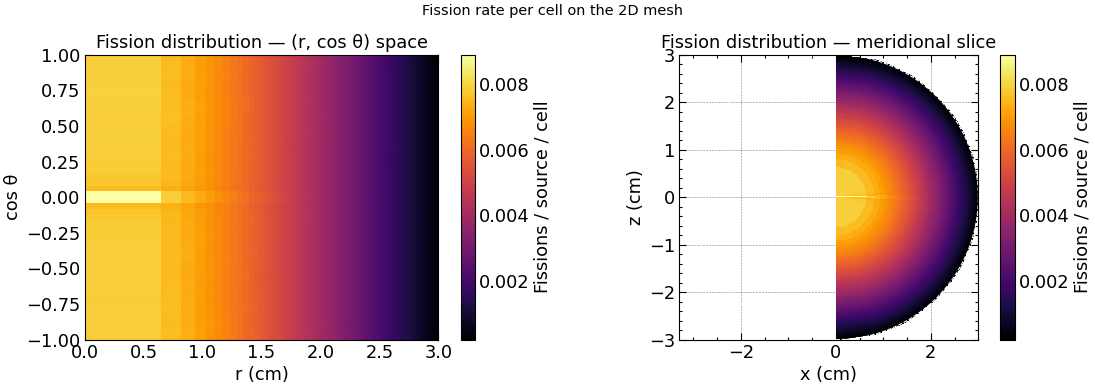

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=80)

# Left: flat (r, cos θ) pcolormesh
im0 = axes[0].pcolormesh(
    r_edges, cos_theta_edges, fission_2d,
    cmap="inferno", shading="flat",
)
plt.colorbar(im0, ax=axes[0], label="Fissions / source / cell")
axes[0].set_xlabel("r (cm)")
axes[0].set_ylabel("cos θ")
axes[0].set_title("Fission distribution — (r, cos θ) space")

# Right: meridional slice
im1 = axes[1].pcolormesh(
    X_phys, Z_phys, fission_2d,
    cmap="inferno", shading="flat",
)
plt.colorbar(im1, ax=axes[1], label="Fissions / source / cell")
axes[1].plot(
    CORE_RADIUS * np.cos(np.linspace(0, 2 * np.pi, 300)),
    CORE_RADIUS * np.sin(np.linspace(0, 2 * np.pi, 300)),
    "w--", lw=1.0,
)
axes[1].set_aspect("equal")
axes[1].set_xlabel("x (cm)")
axes[1].set_ylabel("z (cm)")
axes[1].set_title("Fission distribution — meridional slice")

plt.suptitle("Fission rate per cell on the 2D mesh", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fission_2d.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.2 Radial profile (marginalised over θ)

Sum the 2D fission tally over the theta axis to recover the 1D radial profile.
This should reproduce the same trend as the old radial-only mesh results.

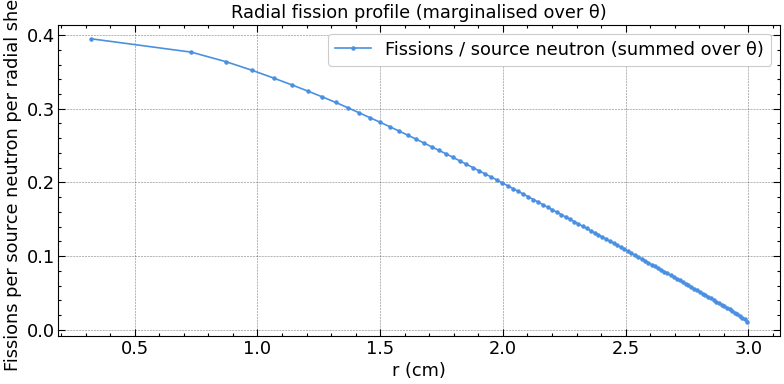

In [8]:
fission_radial = fission_2d.sum(axis=0)  # sum over theta

fig, ax = plt.subplots(figsize=(10, 5), dpi=80)
ax.plot(r_mid, fission_radial, "o-", color="#4A90E2", lw=1.5, ms=3,
        label="Fissions / source neutron (summed over θ)")
ax.set_xlabel("r (cm)")
ax.set_ylabel("Fissions per source neutron per radial shell")
ax.set_title("Radial fission profile (marginalised over θ)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fission_radial_profile.png", dpi=300, bbox_inches="tight")
plt.show()